# Fair Hiring: Bias-Corrected Conformal Intervals and Poset Selection

**Recitation Notebook**

---

## Learning Objectives

By the end of this recitation, you will be able to:
- Explain why fairness issues can arise at the prediction layer and be amplified by downstream top-k selection
- Train and compare baseline screening models
- Compute and interpret group-level bias (systematic over/underprediction) and error variability (standard deviation), and connect these diagnostics to expected selection distortions
- Describe, in words, how bias correction recenters predictions and how conformal calibration produces group-sensitive uncertainty intervals with a coverage target
- Implement and justify poset-style selection
---

## Background



The setting of this notebook is automated applicant screening. Modern applicant pools are very large, making automated screening or ranking necessary simply to manage volume. But, this creates the core tension of this recitation:

$\Rightarrow$ Employers want screening that is both **effective** (find strong candidates) and **defensible** (job-related, consistent, and fair across protected groups).

 We will see that, even before we impose any fairness constraint, the prediction layer can create unequal downstream outcomes if errors differ across groups. We do not observe “true quality.” We observe a proxy (e.g., standardized programming score) and predict it from historical features. Selection by top-k point predictions amplifies differences in error structure: If one group’s predictions are systematically more optimistic (bias) or less noisy (variance), that group can be overrepresented in the selected set even when true performance is similar.

$\Rightarrow$ **Our Goal** is not to “force” an outcome, but to prevent error structure from becoming a hidden mechanism that distorts selection outcomes across groups.

**Reference**: Based on [Salem & Gupta (2023)](https://dl.acm.org/doi/abs/10.1287/mnsc.2023.4926)

Some interesting news articles related to this issue:
- [Algorithms that adjust for worker race/gender still show bias](https://news.utexas.edu/2023/02/08/algorithms-that-adjust-for-worker-race-gender-still-show-biases/), 
- [AI tools show biases in ranking job applicants’ names according to perceived race and gender](https://www.washington.edu/news/2024/10/31/ai-bias-resume-screening-race-gender/)

---

## Part 0: Setup

In [1]:
# !pip install sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from IPython.display import display

np.random.seed(42)
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 11

print("✓ Setup complete.")

✓ Setup complete.


---

## Part 1: Data Loading and Score Distributions

In [2]:
# Load data
df = pd.read_csv("aspiring-mind-subset.csv")
df['Male'] = 1 - df['Gender']
df['Gender_str'] = df['Gender'].map({0: 'M', 1: 'F'})

# Define features
exclude = ['ComputerProgramming', 'ComputerScience', 'Salary', 'Gender', 'Male', 'Gender_str']
features_no_gender = [c for c in df.columns if c not in exclude]
features_with_gender = features_no_gender + ['Male']
target = 'ComputerProgramming'

print(f"Dataset: {len(df)} candidates")
print(f"  Male:   {sum(df['Gender_str']=='M')}")
print(f"  Female: {sum(df['Gender_str']=='F')}")
print(f"\nFeatures: {len(features_no_gender)} (without gender), {len(features_with_gender)} (with gender)")

df_raw=df

Dataset: 2212 candidates
  Male:   1628
  Female: 584

Features: 20 (without gender), 21 (with gender)


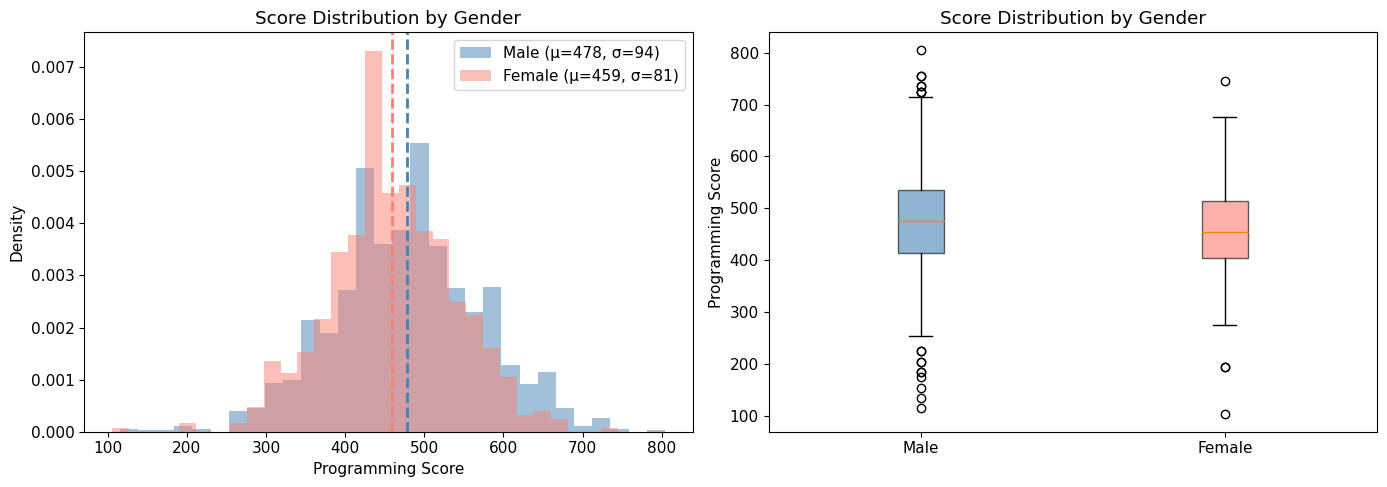


SCORE SUMMARY
Group            Mean        Std     Median          N
--------------------------------------------------
M               478.0       93.6      475.0       1628
F               459.3       80.6      455.0        584


In [3]:
# Score distributions by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for g, color, label in [('M', 'steelblue', 'Male'), ('F', 'salmon', 'Female')]:
    scores = df[df['Gender_str']==g][target]
    ax.hist(scores, bins=30, alpha=0.5, color=color, label=f'{label} (μ={scores.mean():.0f}, σ={scores.std():.0f})', density=True)
    ax.axvline(scores.mean(), color=color, linestyle='--', linewidth=2)
ax.set_xlabel('Programming Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Gender')
ax.legend()

# Box plot
ax = axes[1]
data_m = df[df['Gender_str']=='M'][target]
data_f = df[df['Gender_str']=='F'][target]
bp = ax.boxplot([data_m, data_f], labels=['Male', 'Female'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
for box in bp['boxes']:
    box.set_alpha(0.6)
ax.set_ylabel('Programming Score')
ax.set_title('Score Distribution by Gender')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSCORE SUMMARY")
print("="*50)
print(f"{'Group':<10} {'Mean':>10} {'Std':>10} {'Median':>10} {'N':>10}")
print("-"*50)
for g in ['M', 'F']:
    scores = df[df['Gender_str']==g][target]
    print(f"{g:<10} {scores.mean():>10.1f} {scores.std():>10.1f} {scores.median():>10.1f} {len(scores):>10}")

---

## Part 2: Train / Calibration / Test Split

For conformal prediction, we need a separate calibration set:
- **Training (60%):** Fit the model and estimate bias
- **Calibration (20%):** Compute conformal quantiles
- **Test (20%):** Evaluate selection

In [4]:
# 3-way split: 60% train, 20% calibration, 20% test
train_val_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Gender'])
train_df, calib_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df['Gender'])
train_df, calib_df, test_df = train_df.copy(), calib_df.copy(), test_df.copy()

print("DATA SPLITS")
print("="*60)
print(f"{'Set':<15} {'Total':>10} {'Male':>10} {'Female':>10}")
print("-"*45)
for name, d in [('Training', train_df), ('Calibration', calib_df), ('Test', test_df)]:
    print(f"{name:<15} {len(d):>10} {sum(d['Gender_str']=='M'):>10} {sum(d['Gender_str']=='F'):>10}")

DATA SPLITS
Set                  Total       Male     Female
---------------------------------------------
Training              1326        976        350
Calibration            443        326        117
Test                   443        326        117


---


## Part 3: Model Training

We train a linear regression model to learn a mapping from applicant features $X$ (e.g., background variables, test components, etc.) to a continuous outcome $y$ (the programming score). A trained regression model outputs a point prediction $\hat y$, which we interpret as the model’s best estimate of the score for a candidate with features $x$:
$$
f_\theta(x) = \beta_0 + \beta^\top x,
$$
and we learn parameters $\theta=(\beta_0,\beta)$ by minimizing the mean squared error on training data:
$$
\min_{\theta} \frac{1}{n}\sum_{i=1}^n \big(y_i - f_\theta(x_i)\big)^2.
$$

In [5]:
# Train 2 models
models = {
    'LR_WithG': LinearRegression(),
    'LR_NoG': LinearRegression()
}

for name, model in models.items():
    feats = features_with_gender if 'WithG' in name else features_no_gender
    model.fit(train_df[feats], train_df[target])

A first indicator for model performance is $R^2$ (R-squared), also called the coefficient of determination. It measures how much of the variation in the outcome $y$ the model can explain relative to a trivial baseline that predicts the historical mean $\bar y$ for every candidate.

Formally, with true scores $y_i$, predictions $\hat y_i$, and mean $\bar y$:
$$
R^2 = 1 - \frac{\sum_{i}(y_i - \hat y_i)^2}{\sum_{i}(y_i - \bar y)^2}
= 1 - \frac{\text{SSE}}{\text{SST}}.
$$

- $\text{SSE} = \sum_i (y_i - \hat y_i)^2$: how much squared error the model makes.

- $\text{SST} = \sum_i (y_i - \bar y)^2$: how much squared error you would make by always predicting $\bar y$.

**How to interpret $R^2$:**
- $R^2 = 0$: no better than predicting the mean score for everyone.
- $R^2 = 1$: perfect predictions (no error).
- $R^2 < 0$: worse than predicting the mean (can happen on test data).

In [6]:
# -------- Evaluate
print("MODEL PERFORMANCE (R² on Test Set)")
print("="*50)
print(f"{'Model':<25} {'R²':>12}")
print("-"*40)
for name, model in models.items():
    feats = features_with_gender if 'WithG' in name else features_no_gender
    r2 = model.score(test_df[feats], test_df[target])
    print(f"{name:<25} {r2:>12.3f}")

MODEL PERFORMANCE (R² on Test Set)
Model                               R²
----------------------------------------
LR_WithG                         0.600
LR_NoG                           0.597


Here, $R^2 = 0.60$ means the model reduces squared error by about 60% relative to the “predict the mean” baseline.

---

## Part 4: Bias and Standard Deviation Analysis

Lets now first look at the bias and the standard deviation on the training set. We can look at model bias on the training set as a quick diagnostic. 

For each candidate $i$, the **prediction error** is defined as
$$
e_i = \hat y_i - y_i,
$$
where $\hat y_i$ is the model prediction and $y_i$ is the true programming score.

We then look at the prediction error within each group $g$:
$$
{e_i : g_i = g}.
$$

The **bias** for group $g$ is then the average prediction error:
$$
b_g = \frac{1}{n_g}\sum_{i: g_i=g} e_i.
$$

Interpretation:
- $b_g > 0$: the model overpredicts for group $g$ on average.
- $b_g < 0$: the model underpredicts for group $g$ on average.
- $b_g \approx 0$: the model is (approximately) unbiased on average for that group.

If one group is systematically underpredicted, fewer members of that group will appear in the top tail and be selected, even if their true scores are high.

---

The **standard deviation** of the prediction errors for group $g$ is:
$$
\sigma_g =\sqrt{\frac{1}{n_g-1}\sum_{i: g_i=g}(e_i - b_g)^2}.
$$

Interpretation:
- Larger $\sigma_g$ means the model is less reliable for group $g$ (more spread in errors).
- Smaller $\sigma_g$ means predictions are more consistent for group $g$.
Even if bias is near zero, a group with larger $\sigma_g$ will have more “surprising” large errors

In [7]:
# Compute predictions and errors on training set
error_stats = {}

for name, model in models.items():
    feats = features_with_gender if 'WithG' in name else features_no_gender
    train_df[f'Pred_{name}'] = model.predict(train_df[feats])
    train_df[f'Error_{name}'] = train_df[f'Pred_{name}'] - train_df[target]
    
    error_stats[name] = {}
    for g in ['M', 'F']:
        errors = train_df[train_df['Gender_str']==g][f'Error_{name}']
        error_stats[name][g] = {'bias': errors.mean(), 'std': errors.std()}

print("MODEL BIAS AND STD BY GENDER (Training Set)")
print("="*80)
print(f"{'Model':<20} {'Male Bias':>12} {'Male Std':>10} {'Female Bias':>14} {'Female Std':>12}")
print("-"*70)
for name in models.keys():
    m_b, m_s = error_stats[name]['M']['bias'], error_stats[name]['M']['std']
    f_b, f_s = error_stats[name]['F']['bias'], error_stats[name]['F']['std']
    print(f"{name:<20} {m_b:>+12.2f} {m_s:>10.2f} {f_b:>+14.2f} {f_s:>12.2f}")
    

MODEL BIAS AND STD BY GENDER (Training Set)
Model                   Male Bias   Male Std    Female Bias   Female Std
----------------------------------------------------------------------
LR_WithG                    -0.00      61.32          +0.00        52.26
LR_NoG                      -3.47      61.37          +9.68        52.26


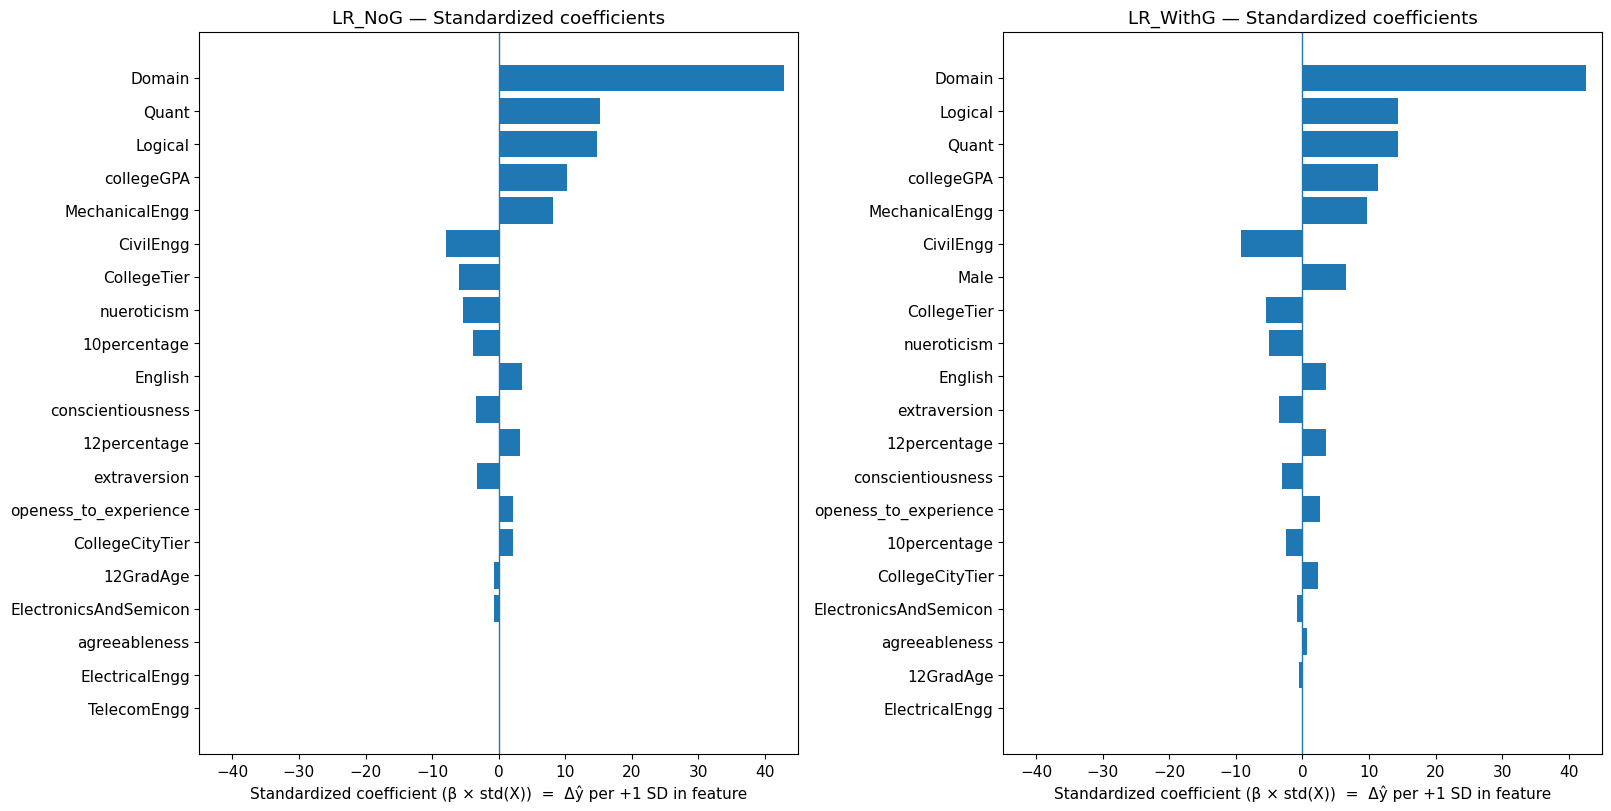

Standardized coefficient for Male (LR_WithG): +6.5927


In [8]:
def standardized_coef_series(lr_model, X_train_df, feature_names):
    """
    Standardized coefficients: beta_j * std(X_j) computed on TRAIN.
    Interpretable as change in prediction for a +1 SD increase in feature j.
    """
    beta = lr_model.coef_.ravel()
    xstd = X_train_df[feature_names].std(ddof=0).values
    return pd.Series(beta * xstd, index=feature_names)

def plot_std_coefs(ax, s, title, top_n=20):
    s = s.copy()
    s = s.reindex(s.abs().sort_values(ascending=False).index)
    if top_n is not None:
        s = s.head(top_n)
    s = s.iloc[::-1]  # biggest at top in barh
    ax.barh(s.index, s.values)
    ax.axvline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Standardized coefficient (β × std(X))  =  Δŷ per +1 SD in feature")

# compute standardized coefficients
std_noG   = standardized_coef_series(models["LR_NoG"],   train_df, features_no_gender)
std_withG = standardized_coef_series(models["LR_WithG"], train_df, features_with_gender)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

plot_std_coefs(axes[0], std_noG,   "LR_NoG — Standardized coefficients", top_n=20)
plot_std_coefs(axes[1], std_withG, "LR_WithG — Standardized coefficients", top_n=20)

# make x-limits comparable
m = max(std_noG.abs().max(), std_withG.abs().max())
axes[0].set_xlim(-1.05*m, 1.05*m)
axes[1].set_xlim(-1.05*m, 1.05*m)

plt.show()

# optional: print the direct gender effect in standardized units
if "Male" in std_withG.index:
    print(f"Standardized coefficient for Male (LR_WithG): {std_withG['Male']:+.4f}")

### Part 4.1: Ranking Candidates in the Test Set

In [16]:
def _topk_idx(series: pd.Series, k: int) -> pd.Index:
    s = series.dropna().sort_values(ascending=False, kind="mergesort")  # stable, tie-safe
    return s.index[:k]

def top10_pred_summary_block(
    test_df, models, model_name, target,
    features_with_gender, features_no_gender,
    pct=0.10, group_col="Gender_str", groups=("M", "F")):
    pred_col = f"Pred_{model_name}"

    # Ensure predictions exist
    if pred_col not in test_df.columns:
        feats = features_with_gender if "WithG" in model_name else features_no_gender
        test_df[pred_col] = models[model_name].predict(test_df[feats])

    N = len(test_df)
    k = int(np.ceil(pct * N))

    pred_sorted = test_df[pred_col].sort_values(ascending=False, kind="mergesort")
    true_sorted = test_df[target].sort_values(ascending=False, kind="mergesort")

    pred_top = pred_sorted.index[:k]
    true_top = true_sorted.index[:k]

    pred_tau = float(pred_sorted.iloc[k-1])
    global true_tau
    true_tau = float(true_sorted.iloc[k-1])

    hits = int(len(set(pred_top) & set(true_top)))
    hit_rate = hits / k if k else np.nan

    # --- Gender composition ---
    pred_g = test_df.loc[pred_top, group_col].astype(str)
    true_g = test_df.loc[true_top, group_col].astype(str)

    pred_m = int((pred_g == groups[0]).sum())
    pred_f = int((pred_g == groups[1]).sum())
    true_m = int((true_g == groups[0]).sum())
    true_f = int((true_g == groups[1]).sum())

    pred_f_pct = (pred_f / k) if k else np.nan
    true_f_pct = (true_f / k) if k else np.nan
    delta_f_pct = pred_f_pct - true_f_pct if np.isfinite(pred_f_pct) and np.isfinite(true_f_pct) else np.nan

    # Print in your preferred style
    print(f"\n{model_name}:")
    print(f"  {'N':<8}{f'k ({int(pct*100)}%)':>10}{'Pred τ (kth)':>16}{'True τ* (kth)':>18}{'Hits':>10}{'Hit rate':>12}")
    print("  " + "-" * 76)
    print(f"  {N:<8}{k:>10}{pred_tau:>16,.3f}{true_tau:>18,.3f}{(str(hits)+'/'+str(k)):>10}{hit_rate:>11.1%}")

    print(f"  {'Gender (top k)':<18}{'Male':>10}{'Female':>10}{'Female %':>12}{'ΔF% vs true':>14}")
    print("  " + "-" * 76)
    print(f"  {'Predicted':<18}{pred_m:>10}{pred_f:>10}{pred_f_pct:>11.1%}{delta_f_pct:>13.1%}")
    print(f"  {'True':<18}{true_m:>10}{true_f:>10}{true_f_pct:>11.1%}{'':>14}")

print("TOP 10% SELECTION (Point Predictions)")
print("=" * 70)
for m in ["LR_WithG", "LR_NoG"]:
    top10_pred_summary_block(
        test_df=test_df,
        models=models,
        model_name=m,
        target=target,
        features_with_gender=features_with_gender,
        features_no_gender=features_no_gender,
        pct=0.10,   # set to 0.20 if you truly want top 20%
        group_col="Gender_str",
        groups=("M", "F"))

TOP 10% SELECTION (Point Predictions)

LR_WithG:
  N          k (10%)    Pred τ (kth)     True τ* (kth)      Hits    Hit rate
  ----------------------------------------------------------------------------
  443             45         557.906           575.000     25/45      55.6%
  Gender (top k)          Male    Female    Female %   ΔF% vs true
  ----------------------------------------------------------------------------
  Predicted                 39         6      13.3%        -2.2%
  True                      38         7      15.6%              

LR_NoG:
  N          k (10%)    Pred τ (kth)     True τ* (kth)      Hits    Hit rate
  ----------------------------------------------------------------------------
  443             45         558.091           575.000     26/45      57.8%
  Gender (top k)          Male    Female    Female %   ΔF% vs true
  ----------------------------------------------------------------------------
  Predicted                 36         9      20.0%    

---

## Part 5: Bias-Corrected Conformal Prediction Intervals

1. **Bias correction (recentering)**
On the training set, we estimate the average prediction error for each group $g$:
$$
\text{bias}g = \frac{1}{n_g}\sum{i=g}(\hat y_i - y_i).
$$
We then correct predictions by subtracting this group bias:
$$
\tilde y_i = \hat y_i - \text{bias}_{g_i}.
$$
$\Rightarrow$ Intuition: After this step, the model is no longer systematically over- or underpredicting for a group (at least on the training data).

---

2. **Conformal quantile (uncertainty calibration)**
On a separate calibration set, we compute absolute residuals after bias correction:
$$
r_i = |y_i - \tilde y_i|.
$$
For each group $g$, we set $q_g$ to be the $(1-\alpha)$ quantile of these residuals within that group:
$$
q_g = \text{Quantile}_{1-\alpha}\Big({r_i: g_i=g}\Big).
$$
$\Rightarrow$ Intuition: $q_g$ captures how noisy predictions are for group $g$; noisier groups get larger $q_g$ and thus wider intervals.

---

3. **Bias-corrected conformal interval**
For a candidate in group $g$, we output:
$$
\big[\tilde y_i - q_g ;\tilde y_i + q_g\big].
$$
$\Rightarrow$  Coverage interpretation: with target coverage $1-\alpha$, the true score falls inside this interval at least a fraction $1-\alpha$ of the time (and with group calibration, we aim for this reliability within each group).


We use 40% coverage (i.e., $\alpha=0.6$) to keep intervals relatively narrow. This trades off statistical reliability for sharper ranking: higher coverage (smaller $\alpha$) would produce wider intervals and more conservative selection, while lower coverage produces narrower intervals but more misses.

In [10]:
target_coverage  = 0.40  # 40% coverage for narrower intervals
alpha = 1.0 - target_coverage

In [11]:
# Compute predictions on calibration and test sets
for name, model in models.items():
    feats = features_with_gender if 'WithG' in name else features_no_gender
    calib_df[f'Pred_{name}'] = model.predict(calib_df[feats])
    test_df[f'Pred_{name}'] = model.predict(test_df[feats])

# Step 1: Compute corrected predictions on calibration set using bias from training
for name in models.keys():
    for g in ['M', 'F']:
        mask = calib_df['Gender_str'] == g
        bias = error_stats[name][g]['bias']
        calib_df.loc[mask, f'Corrected_{name}'] = calib_df.loc[mask, f'Pred_{name}'] - bias

# Step 2: Compute conformal quantiles from calibration residuals (corrected)
conf_params = {}

print(f"CONFORMAL QUANTILES (Target Coverage: {(alpha)*100:.0f}%)")
print("="*70)

for name in models.keys():
    conf_params[name] = {}
    calib_df[f'Residual_{name}'] = np.abs(calib_df[target] - calib_df[f'Corrected_{name}'])
    
    print(f"\n{name}:")
    print(f"  {'Group':<8} {'Bias':>10} {'n_calib':>10} {'q (60%)':>12} {'Width':>12}")
    print("  " + "-"*55)
    
    for g in ['M', 'F']:
        residuals = calib_df[calib_df['Gender_str']==g][f'Residual_{name}'].values
        n = len(residuals)
        # Conformal quantile with finite-sample correction
        q_level = np.ceil((n + 1) * (1 - alpha)) / n
        q = np.quantile(residuals,  q_level, method="higher")
        conf_params[name][g] = q
        bias = error_stats[name][g]['bias']
        print(f"  {g:<8} {bias:>+10.2f} {n:>10} {q:>12.2f} {2*q:>12.1f}")

CONFORMAL QUANTILES (Target Coverage: 60%)

LR_WithG:
  Group          Bias    n_calib      q (60%)        Width
  -------------------------------------------------------
  M             -0.00        326        28.05         56.1
  F             +0.00        117        20.68         41.4

LR_NoG:
  Group          Bias    n_calib      q (60%)        Width
  -------------------------------------------------------
  M             -3.47        326        28.90         57.8
  F             +9.68        117        20.61         41.2


In [12]:
# Build bias-corrected conformal intervals on test set
for name in models.keys():
    for g in ['M', 'F']:
        mask = test_df['Gender_str'] == g
        bias = error_stats[name][g]['bias']
        q = conf_params[name][g]
        
        test_df.loc[mask, f'Corrected_{name}'] = test_df.loc[mask, f'Pred_{name}'] - bias
        test_df.loc[mask, f'Lower_{name}'] = test_df.loc[mask, f'Corrected_{name}'] - q
        test_df.loc[mask, f'Upper_{name}'] = test_df.loc[mask, f'Corrected_{name}'] + q

# Verify coverage
print("COVERAGE (Test Set)")
print("="*60)
print(f"{'Model':<20} {'Male Cov':>12} {'Female Cov':>12} {'Overall':>12}")
print("-"*60)

for name in models.keys():
    for g_name, g_mask in [('Male', test_df['Gender_str']=='M'), 
                           ('Female', test_df['Gender_str']=='F'),
                           ('Overall', [True]*len(test_df))]:
        subset = test_df[g_mask]
        covered = ((subset[target] >= subset[f'Lower_{name}']) & 
                   (subset[target] <= subset[f'Upper_{name}'])).mean()
        if g_name == 'Male':
            male_cov = covered
        elif g_name == 'Female':
            female_cov = covered
        else:
            overall_cov = covered
    print(f"{name:<20} {male_cov*100:>11.1f}% {female_cov*100:>11.1f}% {overall_cov*100:>11.1f}%")

print(f"\n📊 Intervals generated through conformal prediction are bias-corrected and calibrated.")

COVERAGE (Test Set)
Model                    Male Cov   Female Cov      Overall
------------------------------------------------------------
LR_WithG                    45.4%        41.0%        44.2%
LR_NoG                      47.9%        41.0%        46.0%

📊 Intervals generated through conformal prediction are bias-corrected and calibrated.


---

## Part 6: Poset Selection (Top 10% using Threshold)


We can now use the **poset approach** to select candidates whose lower bound exceeds a threshold:

$$\text{Select if: } \text{Lower}_i > \tau$$

We find $\tau$ such that we select approximately the top 10%.

In [13]:
# Ground truth: top 10% by true score
n_select = int(len(test_df) * 0.10)
true_top = set(test_df.nlargest(n_select, target).index)
gt_m = sum(test_df.loc[list(true_top), 'Gender_str']=='M')
gt_f = sum(test_df.loc[list(true_top), 'Gender_str']=='F')

print("GROUND TRUTH: Top 10%")
print("="*50)
print(f"Total to select: {n_select}")
print(f"Gender: {gt_m} / {gt_f}F ({gt_f/n_select*100:.1f}% female)")

GROUND TRUTH: Top 10%
Total to select: 44
Gender: 37 / 7F (15.9% female)


In [14]:
# Poset selection: find threshold to select top n_select by lower bound
print("SELECTION COMPARISON")
print("="*85)
print(f"{'Model':<20} {'Method':<20} {'Hits':>8} {'Male':>8} {'Female':>8} {'F%':>8} {'Match':>8}")
print("-"*85)

selection_results = []

for name in models.keys():
    # Method 1: Top n by raw prediction
    sel = test_df.nlargest(n_select, f'Pred_{name}')
    hits = len(set(sel.index) & true_top)
    n_m, n_f = sum(sel['Gender_str']=='M'), sum(sel['Gender_str']=='F')
    match = '✓' if (n_m == gt_m and n_f == gt_f) else ''
    print(f"{name:<20} {'Top n (Raw)':<20} {hits:>8} {n_m:>8} {n_f:>8} {n_f/n_select*100:>7.1f}% {match:>8}")
    selection_results.append({'Model': name, 'Method': 'Raw', 'Hits': hits, 'Male': n_m, 'Female': n_f})
    
   # Method 2: Poset = Top n by LOWER bound (exactly n_select)
    sorted_lower = test_df[f'Lower_{name}'].sort_values(ascending=False)
    sel_poset = (test_df.sort_values(by=[f'Lower_{name}', f'Pred_{name}'], ascending=[False, False]).head(n_select))  # tie-breaker

    sel_idx = sorted_lower.head(n_select).index
    threshold = sorted_lower.iloc[n_select-1]
    
    hits = len(set(sel_idx) & true_top)
    n_m = (sel_poset['Gender_str'] == 'M').sum()
    n_f = (sel_poset['Gender_str'] == 'F').sum()
    match = '✓' if (n_m == gt_m and n_f == gt_f) else ''

    print(f"{'':<20} {'Poset (Top n by LB)':<20} {hits:>8} {n_m:>8} {n_f:>8} {n_f/n_select*100:>7.1f}% {match:>8}")
    selection_results.append({'Model': name, 'Method': 'Poset', 'Hits': hits, 'Male': n_m, 'Female': n_f, 'Threshold': threshold})

    print()

print("-"*85)
print(f"{'GROUND TRUTH':<20} {'':<20} {n_select:>8} {gt_m:>8} {gt_f:>8} {gt_f/n_select*100:>7.1f}%")

SELECTION COMPARISON
Model                Method                   Hits     Male   Female       F%    Match
-------------------------------------------------------------------------------------
LR_WithG             Top n (Raw)                25       38        6    13.6%         
                     Poset (Top n by LB)        26       37        7    15.9%        ✓

LR_NoG               Top n (Raw)                26       35        9    20.5%         
                     Poset (Top n by LB)        26       37        7    15.9%        ✓

-------------------------------------------------------------------------------------
GROUND TRUTH                                    44       37        7    15.9%


---

## Part 7: Visualizing Poset Intervals

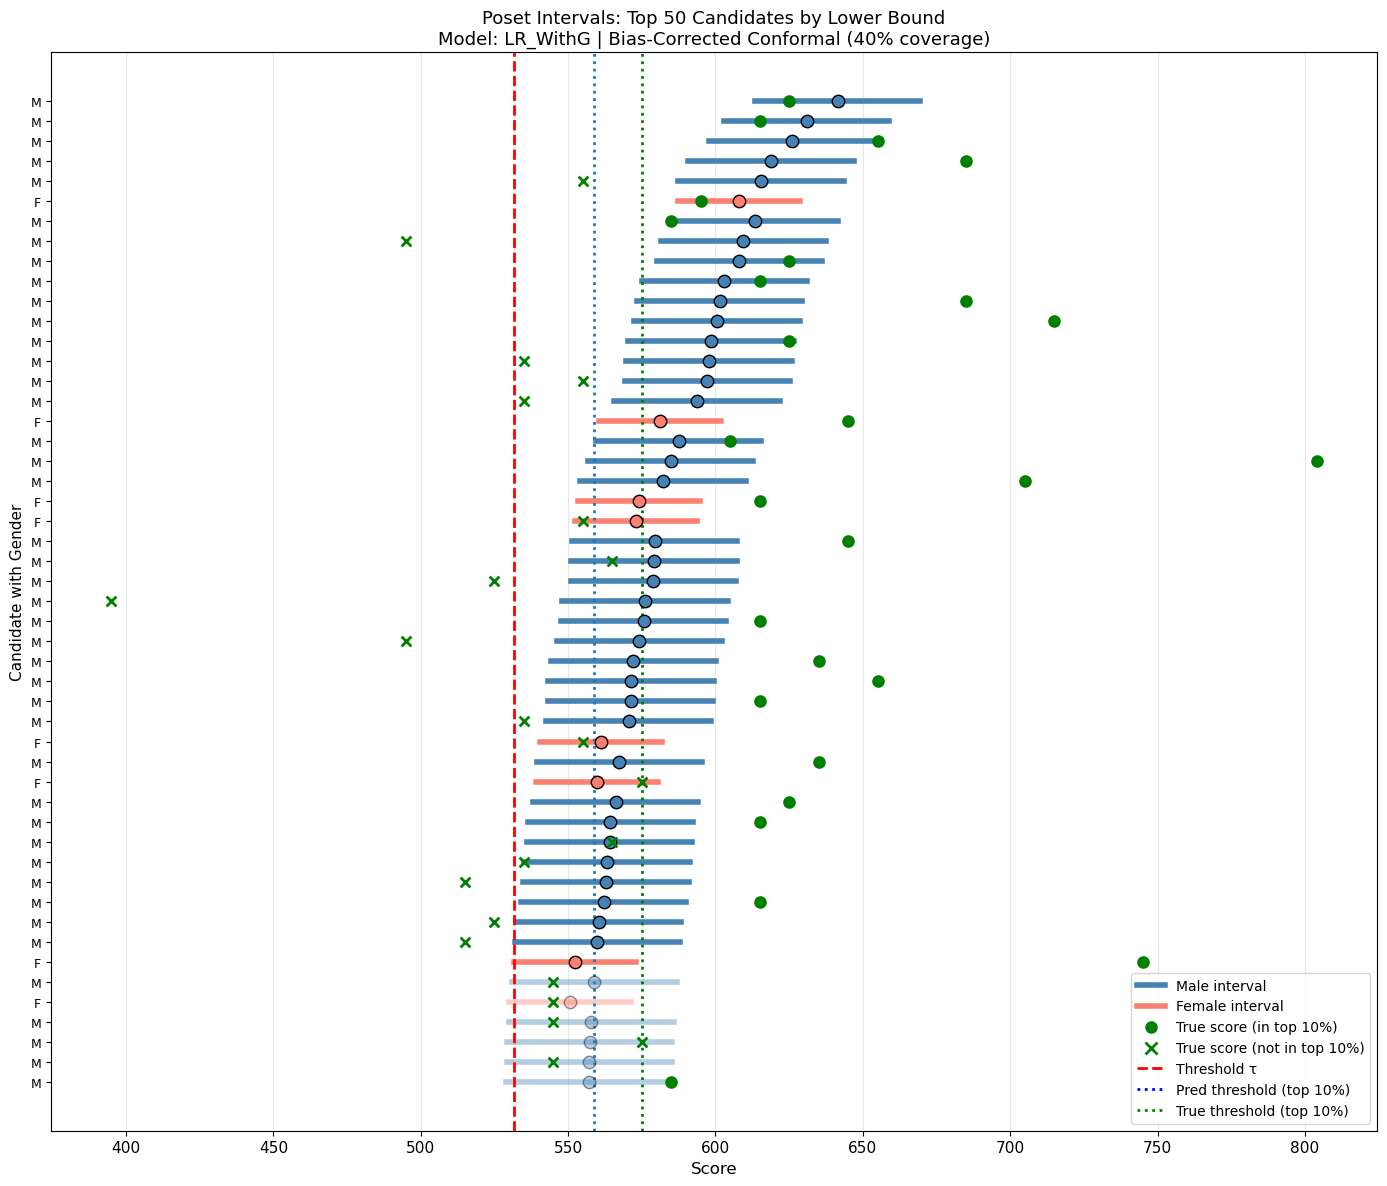

In [21]:
# Plot intervals for top candidates (LR without gender)
model_name = 'LR_WithG'

# Get top 50 by lower bound for visualization
top_candidates = test_df.nlargest(50, f'Lower_{model_name}').copy()
top_candidates = top_candidates.sort_values(f'Lower_{model_name}', ascending=True).reset_index()
top_candidates['Selected'] = top_candidates[f'Lower_{model_name}'] >= threshold
top_candidates['InTrueTop'] = top_candidates['index'].isin(true_top)
sorted_lower = test_df[f'Lower_{model_name}'].sort_values(ascending=False)
sel_poset = (test_df.sort_values(by=[f'Lower_{model_name}', f'Pred_{name}'], ascending=[False, False]).head(n_select))  # tie-breaker

sel_idx = sorted_lower.head(n_select).index
threshold = sorted_lower.iloc[n_select-1]
# 1) thresholds on the model outputs
threshold_lcb  = test_df[f'Lower_{model_name}'].nlargest(n_select).min()
threshold_pred = test_df[f'Pred_{model_name}'].nlargest(n_select).min()
# Plot
fig, ax = plt.subplots(figsize=(14, 12))

colors = {'M': 'steelblue', 'F': 'salmon'}

for i, (_, row) in enumerate(top_candidates.iterrows()):
    color = colors[row['Gender_str']]
    alpha = 1.0 if row['Selected'] else 0.4
    
    # Plot interval
    ax.plot([row[f'Lower_{model_name}'], row[f'Upper_{model_name}']], [i, i], 
            color=color, linewidth=4, alpha=alpha)
    
    # Plot prediction (center)
    ax.scatter(row[f'Pred_{model_name}'], i, color=color, s=80, zorder=5, 
               edgecolor='black', linewidth=1, alpha=alpha)
    
    # Plot true score
    marker = 'o' if row['InTrueTop'] else 'x'
    ax.scatter(row[target], i, color='green', s=50, marker=marker, zorder=6, linewidth=2)

# Threshold line
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'LCB Threshold τ = {threshold:.0f}')
ax.axvline(threshold_pred, linestyle=':',  linewidth=2, label='Pred threshold (top 10%)')
ax.axvline(true_tau, linestyle=':',  linewidth=2, label='True threshold (top 10%)', color="green")
# Labels
y_labels = []
for _, row in top_candidates.iterrows():
    true_status = "(T)" if row['InTrueTop'] else ""
    y_labels.append(f"{row['Gender_str']}")

ax.set_yticks(range(len(top_candidates)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Candidate with Gender', fontsize=11)
ax.set_title(f'Poset Intervals: Top 50 Candidates by Lower Bound\n'
             f'Model: {model_name} | Bias-Corrected Conformal (40% coverage)', fontsize=13)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=4, label='Male interval'),
    Line2D([0], [0], color='salmon', linewidth=4, label='Female interval'),
    Line2D([0], [0], marker='o', color='green', markersize=8, linestyle='None', label='True score (in top 10%)'),
    Line2D([0], [0], marker='x', color='green', markersize=8, linestyle='None', markeredgewidth=2, label='True score (not in top 10%)'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label=f'Threshold τ'),
    Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label=f'Pred threshold (top 10%)'),
    Line2D([0], [0], color='green', linestyle=':', linewidth=2, label=f'True threshold (top 10%)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [22]:
# Detailed selection
model_name = 'LR_WithG'
sorted_lower = test_df[f'Lower_{model_name}'].sort_values(ascending=False)
threshold = sorted_lower.iloc[n_select-1]
selected_idx = test_df[test_df[f'Lower_{model_name}'] >= threshold].index

selected = test_df.loc[selected_idx].copy()
selected['InTrueTop'] = selected.index.isin(true_top)
selected = selected.sort_values(f'Lower_{model_name}', ascending=False)

print(f"SELECTED CANDIDATES ({model_name})")
print("="*90)
print(f"Threshold: {threshold:.1f}")
print(f"Selected: {len(selected)} | Ground Truth: {n_select}")
print(f"\n{'Rank':<6} {'Gender':<8} {'True':>8} {'Pred':>8} {'Lower':>8} {'Upper':>8} {'In GT':>10}")
print("-"*70)

for i, (idx, row) in enumerate(selected.head(20).iterrows(), 1):
    in_gt = '✓' if row['InTrueTop'] else ''
    print(f"{i:<6} {row['Gender_str']:<8} {row[target]:>8.0f} {row[f'Pred_{model_name}']:>8.0f} "
          f"{row[f'Lower_{model_name}']:>8.0f} {row[f'Upper_{model_name}']:>8.0f} {in_gt:>10}")

if len(selected) > 20:
    print(f"... ({len(selected) - 20} more)")

# Summary
hits = sum(selected['InTrueTop'])
n_m = sum(selected['Gender_str']=='M')
n_f = sum(selected['Gender_str']=='F')
print(f"\nSUMMARY: {hits}/{len(selected)} hits | {n_m}M / {n_f}F")
print(f"Ground truth: {gt_m}M / {gt_f}F")

SELECTED CANDIDATES (LR_WithG)
Threshold: 531.6
Selected: 44 | Ground Truth: 44

Rank   Gender       True     Pred    Lower    Upper      In GT
----------------------------------------------------------------------
1      M             625      641      613      670          ✓
2      M             615      631      603      659          ✓
3      M             655      626      598      654          ✓
4      M             685      619      591      647          ✓
5      M             555      615      587      644           
6      F             595      608      587      629          ✓
7      M             585      613      585      641          ✓
8      M             495      609      581      638           
9      M             625      608      580      636          ✓
10     M             615      603      575      631          ✓
11     M             685      601      573      630          ✓
12     M             715      600      572      629          ✓
13     M             625     

---

## Part 8: Key Takeaways

1. **Prediction bias is group-dependent:** Models trained without gender show different prediction biases for male and female candidates.

2. **Bias-corrected conformal prediction intervals help develop transparent ML pipelines:** Conformal predictions can help us get an estimate of model's uncertainty on predicted values, and incorporate this meaningfully into decision-making. 

3. **Poset-style selection changes the decision rule, not the model.:** Using lower bounds of intervals can give candidates the benefit of the doubt, due to our measurement errors (using ML predictions). 


---

## References

1. Salem, J. & Gupta, S. (2023). Secretary Problems with Biased Evaluations Using Partial Ordinal Information. https://dl.acm.org/doi/abs/10.1287/mnsc.2023.4926 

2. Salem, J., Desai, D. R., & Gupta, S. (2022). Don’t let Ricci v. DeStefano Hold You Back: A Bias-Aware Legal Solution to the Hiring Paradox. https://doi.org/10.1145/3531146.3533129 

3. Angelopoulos, A. N., & Bates, S. (2021). A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification. https://arxiv.org/abs/2107.07511

4. Aspiring Minds Employment Outcome (AMEO) 2015 Dataset. https://zenodo.org/records/45735